In [61]:
%load_ext rich
%load_ext autoreload
%autoreload 2


The rich extension is already loaded. To reload it, use:
  %reload_ext rich
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import logging
import os
import sys
import math
from functools import partial
from itertools import product
from typing import Literal

import camb
import healpy as hp
import lenspyx
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from joblib import Parallel, delayed
from ksw import KSW, Cosmology, Data, Shape
from ksw.radial_functional import radial_func
from pixell import curvedsky, enmap, reproject
from rich.jupyter import print
from scipy.interpolate import CubicSpline, interp1d
from tqdm.auto import tqdm

from scripts import Core
from scripts.utils import load_data, remove_mono_dipole, save_data, setup_logging
from scripts.utils.plots import plot_cl, plot_cl_alm, plot_cl_map, plot_patches

logger = setup_logging(__name__, level=logging.DEBUG, use_rich=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("healpy").setLevel(logging.WARNING)


## Setup

In [63]:
s = Core(["settings/planck.json", "--nsims", "1", "--narray", "1", "--beam_width", "0"])
s.is_main_job = True  # fix an issue with missing slurm job array


19-Apr-24 15:49:44 - scripts.core - DEBUG - Parsing CLI args: ['settings/planck.json', '--nsims', '1', '--narray', 
'1', '--beam_width', '0']

19-Apr-24 15:49:44 - scripts.core - INFO - Loading settings from file settings/planck.json

19-Apr-24 15:49:44 - scripts.core - DEBUG - Forcing setting 'nsims' to '1' due to CLI

19-Apr-24 15:49:44 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI

19-Apr-24 15:49:44 - scripts.core - DEBUG - Forcing setting 'beam_width' to '0.0' due to CLI

...

19-Apr-24 15:50:33 - scripts.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'

19-Apr-24 15:50:33 - scripts.core - DEBUG - Setting 'model_dir' not found, using default: 'models'

19-Apr-24 15:50:33 - scripts.core - DEBUG - Setting 'alm_dir' not found, using default: 'alms'

19-Apr-24 15:50:33 - scripts.core - DEBUG - Setting 'patch_dir' not found, using default: 'patches'

╭────────────────────────────────────────── <class 'scripts.core.Core'> ──────────────────────────────────────────╮
│ ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────╮ │
│ │ <scripts.core.Core object at 0x1554715d9890>                                                                │ │
│ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
│                                                                                                                 │
│           alm_dir = 'data/alms'                                                                                 │
│          alm_file = 'data/alms/planck_512.hdf5'                                                                 │
│  alm_file_partial = 'data/alms/planck_512.hdf5'                                                                 │
│         alm_shape = (1, 1, 525825)                                                                              │
│          base_dir = 'data'                                                                                      │
│         base_name = 'planck_512'                                                                                │
│          beam_ell = array([[1., 1., 1., ..., 1., 1., 1.]])                                                      │
│        beam_width = 0.0                                                                                         │
│            c_ells = array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,                                  │
│                              0.00000000e+00],                                                                   │
│                            [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,                                  │
│                              0.00000000e+00],                                                                   │
│                            [ 1.37212513e+03,  6.26944200e-02,  0.00000000e+00,                                  │
│                              4.03193692e+00],                                                                   │
│                            ...,                                                                                 │
│                            [ 6.75220751e-03,  2.73819665e-04,  0.00000000e+00,                                  │
│                             -3.73765609e-04],                                                                   │
│                            [ 6.74524076e-03,  2.71978523e-04,  0.00000000e+00,                                  │
│                             -3.80818278e-04],                                                                   │
│                            [ 6.73904948e-03,  2.70110849e-04,  0.00000000e+00,                                  │
│                             -3.87711672e-04]])                                                                  │
│             cosmo = <ksw.cosmo.Cosmology object at 0x15549ff0fc10>                                              │
│      cosmo_params = {                                                                                           │
│                         'As': 2.457e-09,                                                                        │
│                         'ns': 0.96,                                                                             │
│                         'pivot_scalar': 0.05,                                                                   │
│                         'max_l': 1500,                                                                          │
│                         'lmax': 1024,                                                                           │
│                         'H0': 70.1,                                                                             │
│                         'ombh2': 0.02256,             

## Alm

In [64]:
def integrand(alm, bl_div_cl, alpha_l, r, dr, nside, lmax):
    Balm = hp.almxfl(alm, bl_div_cl, inplace=True)
    B = hp.alm2map(Balm, nside=nside, lmax=lmax, inplace=True)
    inner = hp.map2alm(B**2, lmax=lmax, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l, inplace=True)
    return dr * r**2 * kernel


def interpolator(
    func, ells_sparse, axis=1, type: Literal["linear", "cubic"] = "linear"
):
    if type == "linear":
        return interp1d(ells_sparse, func, kind="linear", axis=axis)
    elif type == "cubic":
        return CubicSpline(ells_sparse, func, axis)
    else:
        raise ValueError(
            f"Interpolation type {type} not supported. Use 'linear' or 'cubic'."
        )


def generate_alm_ng(s, alms):
    ells = s.ells[(s.ells >= s.tr_ells.min()) & (s.ells <= s.tr_ells.max())]

    A = (3 / 5) ** 2 * 2 * np.pi**2 * s.cosmo_params["As"]
    delta_phi = (s.tr_k) ** ((s.cosmo_params["ns"] - 4))

    f_k = np.full((len(s.tr_k), 2), 5 / 3, dtype=s.r_dtype)
    # f_k[:, 0] = 1             # f_k for alpha
    f_k[:, 1] *= A * delta_phi  # f_k for beta

    rad = radial_func(f_k, s.tr_ell_k, s.tr_k, s.radii, s.tr_ells)

    alpha_ell = rad[:, :, :, 0]
    alpha_l = interpolator(alpha_ell, s.tr_ells)(ells)

    beta_ell = rad[:, :, :, 1]
    tr_c_ells = s.c_ells[s.tr_ells, : s.npol]
    div = beta_ell / tr_c_ells[np.newaxis, ...]
    bl_div_cl = interpolator(div, s.tr_ells)(ells)

    # We use joblib.parallel to generate the patches in parallel
    # by default (temp_folder=None) this will use a ram disk /dev/shm
    # if the data files are larger than the available memory, it will error
    # so we give it a temp folder to use, which wont have that problem
    temp_folder = os.environ.get("SCRATCH", None)
    parallel = Parallel(n_jobs=-1, return_as="generator", temp_folder=temp_folder)
    logger.info("Starting non-gaussian Alm generation")
    logger.debug(f"Using temp folder {temp_folder}")
    alm_ng = np.empty(s.alm_shape, dtype=s.c_dtype)
    for i, pol in tqdm(s.sim_pol, total=s.sim_pol_len, desc="Alm_ng"):
        alm_ng[i, pol] = sum(
            parallel(
                delayed(integrand)(
                    alms[i, pol],
                    bl_div_cl[ri, :, pol],
                    alpha_l[ri, :, pol],
                    s.radii[ri],
                    s.drs[ri],
                    s.nside,
                    s.lmax,
                )
                for ri in range(len(s.drs))
            )  # type: ignore
        )
    return alm_ng


This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

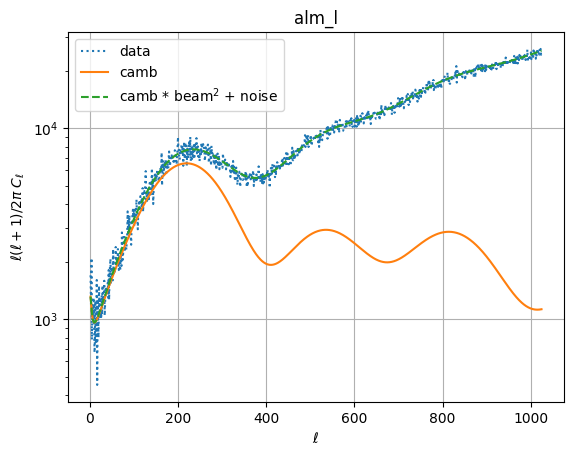

19-Apr-24 15:51:16 - __main__ - INFO - Starting non-gaussian Alm generation

19-Apr-24 15:51:16 - __main__ - DEBUG - Using temp folder /lustre/scratch/client/users/stevensonb

Alm_ng:   0%|          | 0/1 [00:00<?, ?it/s]

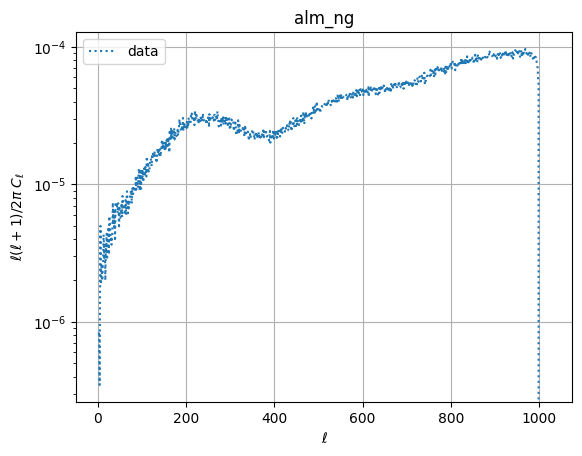

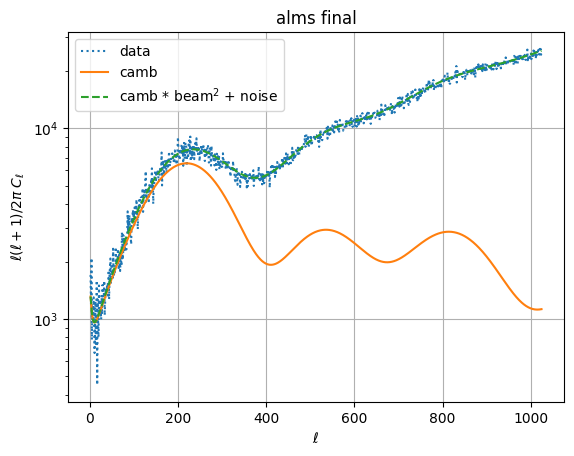

In [65]:
alm_l = np.array(
    [s.data.compute_alm_sim(s.lensing) for _ in range(s.nsims)],
    dtype=s.c_dtype,
)
plot_cl_alm(
    alm_l[0, 0],
    title=f"alm_l",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)
fnls = s.rng.uniform(s.fnl_min, s.fnl_max, s.fnl_shape)
alm_ng = generate_alm_ng(s, alm_l)
plot_cl_alm(alm_ng[0, 0], title=f"alm_ng")
alms = alm_l + fnls * alm_ng
alms = remove_mono_dipole(alms)
plot_cl_alm(
    alms[0, 0],
    title=f"alms final",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)


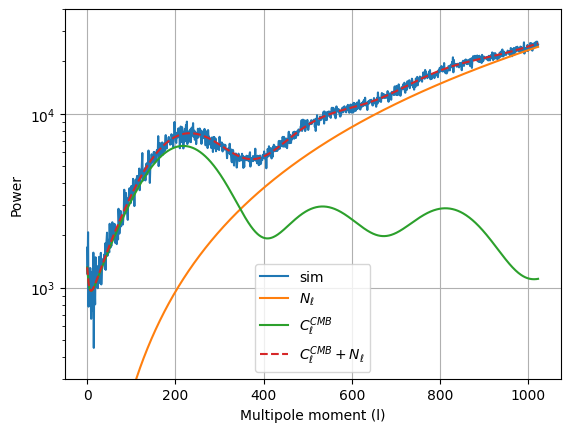

In [66]:
ells = np.arange(2, s.nell)
scale = ells * (ells + 1) / 2 / np.pi
N_ell = s.noise_ell[0, 2:]
cl_cmb = s.c_ells[2 : s.nell, 0]
cl_sim = curvedsky.alm2cl(alms[0, 0])[2 : s.nell]
beam = np.exp(-(ells * (ells + 1) * s.beam_width**2) / (16 * np.log(2)))

plot_func = plt.semilogy
plot_func(scale * cl_sim, label=r"sim")
plot_func(scale * N_ell, label=r"$N_\ell$")
plot_func(scale * cl_cmb, label=r"$C_{\ell}^{CMB}$")
plot_func(
    scale * (cl_cmb * beam**2 + N_ell),
    label=r"$C_\ell^{CMB} + N_\ell$",
    linestyle="--",
)
plt.legend()
plt.xlabel("Multipole moment (l)")
plt.ylabel("Power")
plt.grid(True)
plt.ylim([3e2, 4e4])
plt.show()


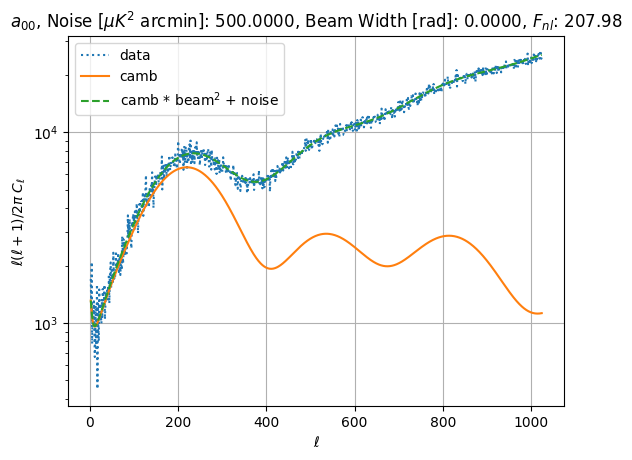

In [67]:
import astropy.units as u

i, j = s.rng.integers(s.nsims), s.rng.integers(s.npol)
noise_muk2arcmin = (s.noise_scale_tt * u.radian).to_value(u.arcmin)
plot_cl_alm(
    alms[i, j],
    title=f"$a_{{{i}{j}}}$, Noise [$\\mu K^2$ arcmin]: {noise_muk2arcmin:.4f}, Beam Width [rad]: {s.beam_width:.4f}, $F_{{nl}}$: {fnls[i, j][0]:.2f}",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)


## PatchGen

In [68]:
def cutSqPatches_lenspyx(
    lmax,
    max_l,
    r_dtype,
    npatches,
    nside,
    fs_shape,
    fs_wcs,
    fs_map,
    pshapes,
    pwcs,
    cl_phi,
    alm,
    fnl,
    plot=False,
):
    """Uses lenspyx to generate and cut the lensed flat maps"""
    geom_info = ("healpix", {"nside": nside})

    # Create a full sky map with lenspyx
    plm = lenspyx.utils_hp.synalm(cl_phi, lmax=max_l, mmax=None, rlm_dtype=r_dtype)
    fl = np.sqrt(np.arange(max_l + 1) * np.arange(1, max_l + 2), dtype=r_dtype)
    dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=True)

    lens_map = lenspyx.alm2lenmap(
        alm,
        dlm,
        geometry=geom_info,
        nthreads=4,
        pol=True,
    )
    pixell_map = reproject.healpix2map(lens_map, fs_shape, fs_wcs, lmax)

    if plot:
        map2hp = reproject.map2healpix(pixell_map, nside, lmax)
        hp.mollview(map2hp, min=-650.0, max=650, title=f"fnl = {fnl}")
        plt.show()
        plot_cl(hp.anafast(map2hp, lmax=lmax, use_pixel_weights=True), lmax=lmax)

    patches = []
    for i in range(npatches):
        patch = pixell_map.project(pshapes[i], pwcs[i])
        patches.append(patch)

    return patches


def cutSqPatches_pixell(
    lmax,
    plot_dir,
    base_name,
    npatches,
    c_ells,
    fs_shape,
    fs_wcs,
    fs_map,
    pshapes,
    pwcs,
    alms,
    fnl,
    plot=False,
):
    """Uses pixell to generate and cut the flat sky patches, unlensed"""
    logger.info(f"pshapes {pshapes}, pwcs {pwcs}, alms {alms}")
    fs_map = enmap.empty(fs_shape, fs_wcs)
    car_map = curvedsky.alm2map(alms, fs_map)

    patches = []
    for i in range(npatches):
        logger.info(f"{npatches}, {np.shape(pshapes)}, {np.shape(pwcs)}")
        patch = car_map.project(pshapes[i], pwcs[i])  # type: ignore
        patches.append(patch)

    if plot:
        plot_dir = os.path.join(plot_dir, "patchgen")
        os.makedirs(plot_dir, exist_ok=True)

        map2hp = reproject.map2healpix(car_map, lmax)
        hp.mollview(map2hp, min=-650.0, max=650, title=f"fnl = {fnl}")
        plt.savefig(os.path.join(plot_dir, f"{base_name}_{fnl}_fullsky.png"))
        plt.close()

        map_path = os.path.join(plot_dir, f"{base_name}_{fnl}_pixell_cl_map.png")
        plot_cl_map(
            car_map, fs_wcs, lmax, plot_camb=True, c_ells=c_ells, save_file=map_path
        )

        patch_path = os.path.join(plot_dir, f"{base_name}_{fnl}_patch.png")
        plot_patches(np.array(patches), 8, save_file=patch_path)

    return np.array(patches)


def get_fs_patch_geo():
    """Generates the patch geometry using pixell"""
    ps_rad = np.deg2rad(s.patch_side_deg)
    res = ps_rad / s.nside
    fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
    fs_map = enmap.empty(fs_shape, fs_wcs)

    patch_shapes = []
    patch_wcss = []
    logger.info(f"{s.npatches // 2}")
    if s.npatches % 2 != 0:
        raise ValueError("npatches must be divisible by 2")

    for counter in range(math.ceil(s.npatches // 2)):
        # [[dec_min,ra_min],[dec_max,ra_max]]
        top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
        gs, w = enmap.geometry(pos=top, res=res, proj="car")
        patch_shapes.append(gs)
        patch_wcss.append(w)

        bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
        gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
        patch_shapes.append(gs)
        patch_wcss.append(w)
    return fs_shape, fs_wcs, fs_map, patch_shapes, patch_wcss


In [69]:
# Here we get the geometry of our patches in a tuple
patch_geo = get_fs_patch_geo()

# we also setup the cutPatches function to use either pixell or lenspyx
# depending on if we are doing lensing or not, and provide a lot of
# arguments that are needed and will stay constant
# we cannot abuse the python scope here since these will need to be pickled
if s.lensing:
    logger.debug("Using lenspyx to generate patches")
    cl_phi = s.cosmo._camb_data.get_lens_potential_cls(
        s.cosmo_params["max_l"], CMB_unit="muK", raw_cl=True
    )[:, 0]

    cutPatches = partial(
        cutSqPatches_lenspyx,
        s.lmax,
        s.cosmo_params["max_l"],
        s.r_dtype,
        s.npatches,
        s.nside,
        *patch_geo,
        cl_phi,
    )
else:
    logger.debug("Using pixell to generate patches")
    cutPatches = partial(
        cutSqPatches_pixell,
        s.lmax,
        s.plot_dir,
        s.base_name,
        s.npatches,
        s.c_ells,
        *patch_geo,
    )

## Start the patch generation
# create the array to store the patches
patches = np.empty(s.patch_shape, dtype=s.r_dtype)

# We use joblib.parallel to generate the patches in parallel
# by default (temp_folder=None) this will use a ram disk /dev/shm
# if the data files are larger than the available memory, about 1TB, it will error
# so we give it a temp folder to use, which wont have that problem
temp_folder = os.environ.get("SCRATCH", None)
logger.debug(f"Using temp folder for patch generation: {temp_folder}")
patch_generator = Parallel(
    n_jobs=-1,
    return_as="generator",
    temp_folder=temp_folder,
)(delayed(cutPatches)(alms[i, j], fnls[i, j], True) for i, j in s.sim_pol)

# Get our data from the generator, only update logging every 100 runs, takes a long time
for idx, result in enumerate(
    tqdm(patch_generator, desc="patch progress", total=s.sim_pol_len)
):
    i, pol = s.sim_pol[idx]
    patches[i, pol] = result


19-Apr-24 15:51:45 - __main__ - INFO - 1

19-Apr-24 15:51:45 - __main__ - DEBUG - Using pixell to generate patches

19-Apr-24 15:51:45 - __main__ - DEBUG - Using temp folder for patch generation:                                    
/lustre/scratch/client/users/stevensonb

patch progress:   0%|          | 0/1 [00:00<?, ?it/s]

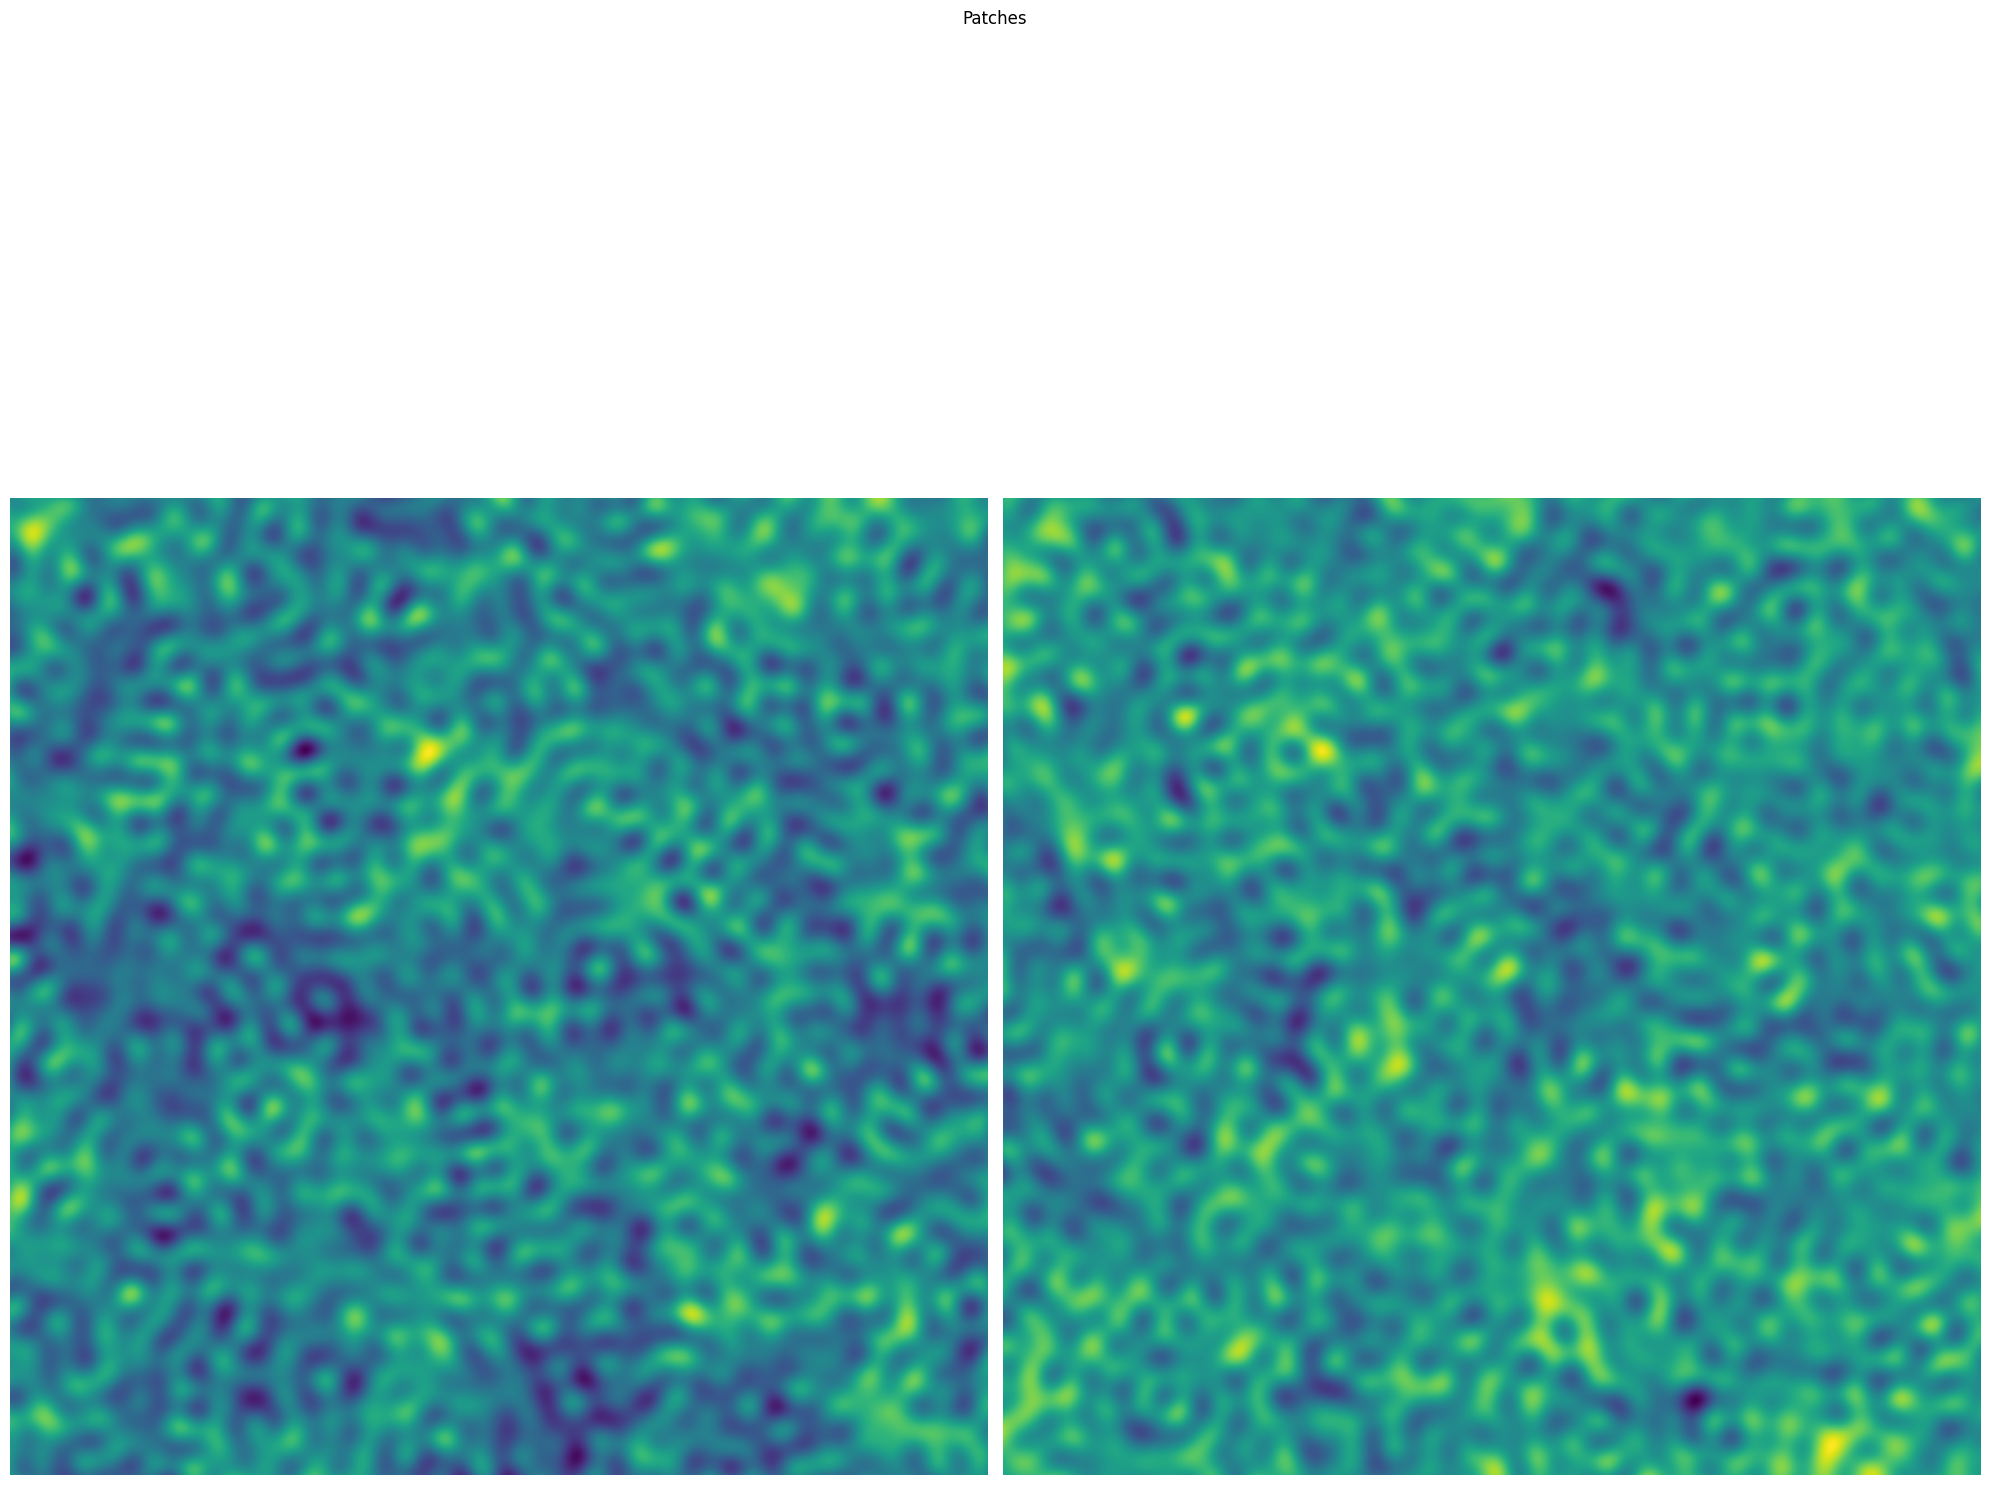

In [72]:
plot_patches(patches[0, 0], 10)


## Estimator

In [71]:
mc_file = os.path.join(s.alm_dir, "kswmc", f"{s.base_name}_m.hdf5")
if os.path.exists(mc_file):
    logger.info("Loading KSW state from %s", mc_file)
    s.ksw.start_from_read_state(mc_file)
else:
    raise NotImplementedError(
        f"No MC file, {mc_file}, found. This notebook requires more work"
    )

fisher = float(s.ksw.compute_fisher())
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))


def alm_loader(i):
    return alms[i, 0]


idxs = [0]
estimates = s.ksw.compute_estimate_batch(alm_loader, idxs, fisher=fisher)


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:6                                                                                    │
│                                                                                                  │
│    3 │   logger.info("Loading KSW state from %s", mc_file)                                       │
│    4 │   s.ksw.start_from_read_state(mc_file)                                                    │
│    5 else:                                                                                       │
│ ❱  6 │   raise NotImplementedError(                                                              │
│    7 │   │   f"No MC file, {mc_file}, found. This notebook requires more work"                   │
│    8 │   )                                                                                       │
│    9                                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NotImplementedError: No MC file, data/alms/kswmc/planck_512_m.hdf5, found. This notebook requires more work